# 1. Введение

## Dota 2. Предсказание победы Radiant

В этом pet-проекте решается задача бинарной классификации. Требуется предсказать вероятность победы команды **Radiant** на основе характеристик матча, доступных на фиксированный момент времени. Данные включают подготовленные табличные признаки из csv и опциональные сырые данные из jsonl, содержащие логи событий и временные ряды.

**Целевая переменная:** `radiant_win`  
**Формат ответа модели:** вероятность в диапазоне `[0, 1]`

Для оценки качества используется метрика **ROC-AUC**, так как она отражает способность модели разделять победы и поражения на разных порогах классификации и является устойчивой метрикой для задач вероятностного предсказания.

## План работы в ноутбуке

1. Загрузка данных и обзор доступных файлов  
2. Описание структуры признаков и первичный EDA  
3. Предобработка данных  
4. Feature engineering  
5. Построение моделей-бейзлайнов  
6. Корректная кросс-валидация без утечек  
7. Подбор гиперпараметров для лучшей модели  
8. Интерпретация важности признаков  
9. Анализ ошибок и предложения по улучшению  
10. Итоговые выводы и практическая интерпретация результата

## Цель проекта

Построить воспроизводимый пайплайн и получить модель с ROC-AUC существенно выше базового уровня случайного угадывания **0.5**, а также показать, какие игровые факторы вносят наибольший вклад в прогноз исхода.


# 2. Окружение и воспроизводимость

In [1]:
import ast
import itertools
import json
import random

import optuna

from sklearn.model_selection import StratifiedKFold
import ipywidgets as widgets
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from catboost import CatBoostClassifier
from IPython.display import clear_output, display
from matplotlib.lines import Line2D
import sklearn
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.model_selection import train_test_split
import catboost
pd.set_option("display.max_columns", None)


RANDOM_STATE = 42

In [2]:
print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("sklearn:", sklearn.__version__)
print("catboost:", catboost.__version__)

pandas: 2.3.3
numpy: 2.2.6
sklearn: 1.7.2
catboost: 1.2.8


# 3. Загрузка данных

### Основные данные

In [3]:
raw_features = pd.read_csv("train_features.csv")
raw_targets = pd.read_csv("train_targets.csv")

Для удобства в дальнейшем прикрепим наш таргет к основной табличке с фичами.

In [4]:
raw_features = raw_features.merge(
    raw_targets[["match_id_hash", "radiant_win"]],
    on="match_id_hash",
    how="inner"
)

raw_features.head()

,match_id_hash,game_time,game_mode,lobby_type,objectives_len,chat_len,r1_hero_id,r1_kills,r1_deaths,r1_assists,r1_denies,r1_gold,r1_lh,r1_xp,r1_health,r1_max_health,r1_max_mana,r1_level,r1_x,r1_y,r1_stuns,r1_creeps_stacked,r1_camps_stacked,r1_rune_pickups,r1_firstblood_claimed,r1_teamfight_participation,r1_towers_killed,r1_roshans_killed,r1_obs_placed,r1_sen_placed,r2_hero_id,r2_kills,r2_deaths,r2_assists,r2_denies,r2_gold,r2_lh,r2_xp,r2_health,r2_max_health,r2_max_mana,r2_level,r2_x,r2_y,r2_stuns,r2_creeps_stacked,r2_camps_stacked,r2_rune_pickups,r2_firstblood_claimed,r2_teamfight_participation,r2_towers_killed,r2_roshans_killed,r2_obs_placed,r2_sen_placed,r3_hero_id,r3_kills,r3_deaths,r3_assists,r3_denies,r3_gold,r3_lh,r3_xp,r3_health,r3_max_health,r3_max_mana,r3_level,r3_x,r3_y,r3_stuns,r3_creeps_stacked,r3_camps_stacked,r3_rune_pickups,r3_firstblood_claimed,r3_teamfight_participation,r3_towers_killed,r3_roshans_killed,r3_obs_placed,r3_sen_placed,r4_hero_id,r4_kills,r4_deaths,r4_assists,r4_denies,r4_gold,r4_lh,r4_xp,r4_health,r4_max_health,r4_max_mana,r4_level,r4_x,r4_y,r4_stuns,r4_creeps_stacked,r4_camps_stacked,r4_rune_pickups,r4_firstblood_claimed,r4_teamfight_participation,r4_towers_killed,r4_roshans_killed,r4_obs_placed,r4_sen_placed,r5_hero_id,r5_kills,r5_deaths,r5_assists,r5_denies,r5_gold,r5_lh,r5_xp,r5_health,r5_max_health,r5_max_mana,r5_level,r5_x,r5_y,r5_stuns,r5_creeps_stacked,r5_camps_stacked,r5_rune_pickups,r5_firstblood_claimed,r5_teamfight_participation,r5_towers_killed,r5_roshans_killed,r5_obs_placed,r5_sen_placed,d1_hero_id,d1_kills,d1_deaths,d1_assists,d1_denies,d1_gold,d1_lh,d1_xp,d1_health,d1_max_health,d1_max_mana,d1_level,d1_x,d1_y,d1_stuns,d1_creeps_stacked,d1_camps_stacked,d1_rune_pickups,d1_firstblood_claimed,d1_teamfight_participation,d1_towers_killed,d1_roshans_killed,d1_obs_placed,d1_sen_placed,d2_hero_id,d2_kills,d2_deaths,d2_assists,d2_denies,d2_gold,d2_lh,d2_xp,d2_health,d2_max_health,d2_max_mana,d2_level,d2_x,d2_y,d2_stuns,d2_creeps_stacked,d2_camps_stacked,d2_rune_pickups,d2_firstblood_claimed,d2_teamfight_participation,d2_towers_killed,d2_roshans_killed,d2_obs_placed,d2_sen_placed,d3_hero_id,d3_kills,d3_deaths,d3_assists,d3_denies,d3_gold,d3_lh,d3_xp,d3_health,d3_max_health,d3_max_mana,d3_level,d3_x,d3_y,d3_stuns,d3_creeps_stacked,d3_camps_stacked,d3_rune_pickups,d3_firstblood_claimed,d3_teamfight_participation,d3_towers_killed,d3_roshans_killed,d3_obs_placed,d3_sen_placed,d4_hero_id,d4_kills,d4_deaths,d4_assists,d4_denies,d4_gold,d4_lh,d4_xp,d4_health,d4_max_health,d4_max_mana,d4_level,d4_x,d4_y,d4_stuns,d4_creeps_stacked,d4_camps_stacked,d4_rune_pickups,d4_firstblood_claimed,d4_teamfight_participation,d4_towers_killed,d4_roshans_killed,d4_obs_placed,d4_sen_placed,d5_hero_id,d5_kills,d5_deaths,d5_assists,d5_denies,d5_gold,d5_lh,d5_xp,d5_health,d5_max_health,d5_max_mana,d5_level,d5_x,d5_y,d5_stuns,d5_creeps_stacked,d5_camps_stacked,d5_rune_pickups,d5_firstblood_claimed,d5_teamfight_participation,d5_towers_killed,d5_roshans_killed,d5_obs_placed,d5_sen_placed,radiant_win
0,a400b8f29dece5f4d266f49f1ae2e98a,155,22,7,1,11,11,0,0,0,0,543,7,533,358,600,350.93784,2,116,122,0.000000,0,0,1,0,0.000000,0,0,0,0,78,0,0,0,3,399,4,478,636,720,254.93774,2,124,126,0.000000,0,0,0,0,0.000000,0,0,0,0,14,0,1,0,0,304,0,130,700,700,242.93773,1,70,156,0.000000,0,0,1,0,0.000000,0,0,0,0,59,0,0,0,1,389,4,506,399,700,326.93780,2,170,86,0.000000,0,0,0,0,0.000000,0,0,0,0,77,0,0,0,0,402,10,344,422,800,314.93780,2,120,100,0.000000,0,0,0,0,0.000000,0,0,0,0,12,0,0,1,13,982,12,780,650,720,386.93787,3,82,170,0.000000,0,0,1,0,1.00,0,0,0,0,21,0,0,0,6,788,9,706,640,640,422.93790,3,174,90,0.000000,0,0,2,0,0.00,0,0,0,0,60,0,0,0,1,531,0,307,720,720,242.93773,2,180,84,0.299948,0,0,2,0,0.00,0,0,0,0,84,1,0,0,0,796,0,421,760,760,326.93780,2,90,150,0.000000,0,0,2,1,1.0,0,0,1,0,34,0,0,0,0,851,11,870,593,680,566.93805,3,128,128,0.000000,0,0,0,0,0.00,0,0,0,0,False
1,b9c57c450ce74a2af79c9ce96fac144d,658,4,0,3,10,15,7,2,0,7,5257,52,3937,1160

## Описание `raw_features` 

Данные содержат параметры матча и статистику 10 игроков на момент времени `game_time`.

### Префиксы и формат
- `r` - Radiant, `d` - Dire  
- цифра 1-5 - номер игрока  
- пример: `r3_gold` - золото 3-го игрока Radiant

### Общие параметры матча
- `match_id_hash` - идентификатор матча, нужен для соединений, из `X` исключается  
- `game_time` - момент фиксации статистики  
- `game_mode`, `lobby_type` - режим и тип лобби  
- `objectives_len`, `chat_len` - агрегированные признаки событий/чата

### Герои
- `r1_hero_id ... r5_hero_id`, `d1_hero_id ... d5_hero_id` - идентификаторы героев

### Основные числовые признаки игроков
Для каждого игрока доступны:
- боевые показатели: `kills`, `deaths`, `assists`, `stuns`  
- фарм/экономика: `lh`, `denies`, `gold`, `xp`  
- состояние героя: `health`, `max_health`, `max_mana`, `level`  
- позиция на карте в данный момент времени: `x`, `y`  
- другая активность: `creeps_stacked`, `camps_stacked`, `rune_pickups`, `firstblood_claimed`,  
  `teamfight_participation`, `towers_killed`, `roshans_killed`, `obs_placed`, `sen_placed`

### Цель
- `radiant_win` - наш таргет, True если победил Radiant, False если Dire


### Сырые/дополнительные данные 

In [5]:
train_jsonl_path = "DOTA 2/train_matches.jsonl"
test_jsonl_path = "DOTA 2/test_matches.jsonl"

df_train_matches = pd.read_json(train_jsonl_path, lines=True)
df_test_matches  = pd.read_json(test_jsonl_path, lines=True)

df_json_matches = pd.concat([df_train_matches, df_test_matches], ignore_index=True)


In [6]:
df_json_matches.head()

,game_time,match_id_hash,teamfights,objectives,chat,game_mode,lobby_type,players,targets
0,155,a400b8f29dece5f4d266f49f1ae2e98a,[],"[{'time': 124.203, 'type': 'CHAT_MESSAGE_FIRST...","[{'player_slot': 0, 'time': -13.63, 'text': '?...",22,7,"[{'player_slot': 0, 'hero_id': 11, 'hero_name'...","{'game_time': 155, 'duration': 992, 'time_rema..."
1,658,b9c57c450ce74a2af79c9ce96fac144d,"[{'start': -12.266, 'end': 41.209, 'last_death...","[{'time': 2.701, 'type': 'CHAT_MESSAGE_FIRSTBL...","[{'player_slot': 1, 'time': 39.075, 'text': '*...",4,0,"[{'player_slot': 0, 'hero_id': 15, 'hero_name'...","{'game_time': 658, 'duration': 1154, 'time_rem..."
2,21,6db558535151ea18ca70a6892197db41,[],[],[],23,0,"[{'player_slot': 0, 'hero_id': 101, 'hero_name...","{'game_time': 21, 'duration': 1503, 'time_rema..."
3,576,46a0ddce8f7ed2a8d9bd5edcbb925682,[],"[{'time': 154.262, 'type': 'CHAT_MESSAGE_FIRST...","[{'player_slot': 3, 'time': 8.031, 'text': '=?...",22,7,"[{'player_slot': 0, 'hero_id': 14, 'hero_name'...","{'game_time': 576, 'duration': 1952, 'time_rem..."
4,453,b1b35ff97723d9b7ade1c9c3cf48f770,[],"[{'time': -10.997, 'type': 'CHAT_MESSAGE_FIRST...","[{'player_slot': 128, 'time': -72.858, 'text':...",22,7,"[{'player_slot': 0, 'hero_id': 42, 'hero_name'...","{'game_time': 453, 'duration': 2001, 'time_rem..."


## Сырые данные `train_matches.jsonl` и `test_matches.jsonl`

Сырые данные представлены в формате jsonl, где каждая строка соответствует одному матчу. В отличие от `train_features.csv`, здесь хранится более детализированная информация о событиях, участниках и динамике игры. Эти поля опциональны для использования, но могут дать прирост качества при корректном извлечении признаков.

Ниже кратко описаны основные колонки.

### Общие поля матча

- `match_id_hash`  
  Уникальный идентификатор матча. Основной ключ для соединения с табличными признаками.

- `game_time`  
  Момент времени, на который зафиксирован "срез" игры в сырых данных.

- `game_mode`  
  Режим игры.

- `lobby_type`  
  Тип лобби или формат матча.

### События матча

- `objectives`  
  Список игровых целей и событий на карте. Обычно включает объекты вроде убийств башен, Рошана и других важных действий. Поле полезно для построения агрегатов активности и контроля карты.

- `teamfights`  
  Информация о командных сражениях. Может содержать временные интервалы и статистику участников. Потенциальный источник признаков интенсивности игры и распределения вклада по командам.

- `chat`  
  История сообщений чата.

### Игроки и их подробная статистика

- `players`  
  Список из 10 словарей, по одному на каждого игрока. Это ключевая часть jsonl для расширенного feature engineering.

  Внутри `players` встречаются:
  - базовые числовые признаки, аналогичные csv  
    `kills`, `deaths`, `assists`, `gold`, `lh`, `xp`, `level`, `health`
  - координаты  
    `x`, `y`
  - логи событий  
    поля с суффиксом `_log`, например `purchase_log`, `kills_log`, `buyback_log`
  - временные ряды  
    поля с суффиксом `_t`, например `gold_t`, `xp_t`, `lh_t`, `dn_t`  
    обычно значения идут с шагом 60 секунд

  Эти данные позволяют строить признаки динамики и поведения игрока, например скорость роста золота или количество покупок за раннюю фазу игры.



### Как сырые данные могут быть использованы в проекте

Наиболее типичные направления извлечения признаков:
- динамические признаки из `_t` рядов  
  темп фарма, прирост золота и опыта, ранние преимущества
- командные суммы и разницы  
  расширение стандартных агрегатов из csv более детальными сигналами


# 4. Первичный EDA

### 4.1 Размеры выборок и баланс классов


In [7]:
print("raw_features shape:", raw_features.shape)

raw_features["radiant_win"].value_counts(normalize=True)

raw_features shape: (39675, 247)


radiant_win
True     0.524915
False    0.475085
Name: proportion, dtype: float64

### 4.2 Обзор типов данных


In [8]:
raw_features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39675 entries, 0 to 39674
Columns: 247 entries, match_id_hash to radiant_win
dtypes: bool(1), float64(30), int64(215), object(1)
memory usage: 74.5+ MB


In [11]:
raw_features.describe().T.head(29)

,count,mean,std,min,25%,50%,75%,max
game_time,39675.0,1146.082798,767.206621,0.000000,521.0000,1044.000000,1656.00000,4933.00000
game_mode,39675.0,19.584776,6.304976,2.000000,22.0000,22.000000,22.00000,23.00000
lobby_type,39675.0,4.772350,3.260582,0.000000,0.0000,7.000000,7.00000,7.00000
objectives_len,39675.0,6.524865,6.492107,0.000000,1.0000,4.000000,10.00000,43.00000
chat_len,39675.0,7.338500,13.366381,0.000000,0.0000,3.000000,9.00000,291.00000
r1_hero_id,39675.0,51.103138,34.603057,1.000000,20.0000,44.000000,81.00000,120.00000
r1_kills,39675.0,3.147876,3.724282,0.000000,0.0000,2.000000,5.00000,32.00000
r1_deaths,39675.0,3.268809,3.283323,0.000000,1.0000,2.000000,5.00000,27.00000
r1_assists,39675.0,4.670170,5.225349,0.000000,1.0000,3.000000,7.00000,40.00000
r1_denies,39675.0,6.289628,8.203957,0.000000,1.0000,3.000000,9.00000,84.00000


### 4.3 Пропуски

In [16]:
na_rate = (raw_features.isna().mean().sort_values(ascending=False))
na_rate[na_rate > 0].shape

(0,)

Пропуски отсутствуют в обработанных данных

### 4.4 Распределения ключевых матчевых признаков


In [19]:
basic_match_cols = ["game_time", "game_mode", "lobby_type", "objectives_len", "chat_len"]
raw_features[basic_match_cols].describe()


,game_time,game_mode,lobby_type,objectives_len,chat_len
count,39675.000000,39675.000000,39675.000000,39675.000000,39675.000000
mean,1146.082798,19.584776,4.772350,6.524865,7.338500
std,767.206621,6.304976,3.260582,6.492107,13.366381
min,0.000000,2.000000,0.000000,0.000000,0.000000
25%,521.000000,22.000000,0.000000,1.000000,0.000000
50%,1044.000000,22.000000,7.000000,4.000000,3.000000
75%,1656.000000,22.000000,7.000000,10.000000,9.000000
max,4933.000000,23.000000,7.000000,43.000000,291.000000


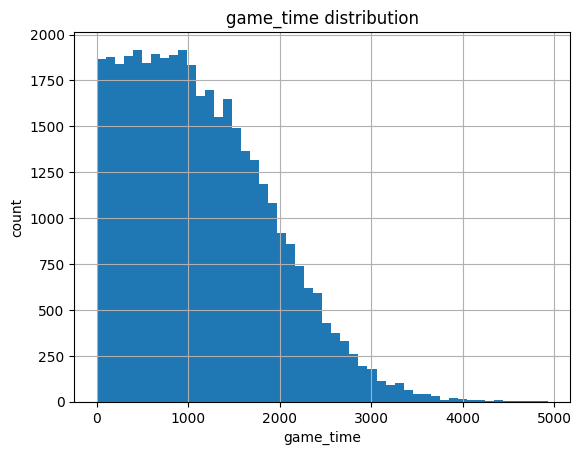

In [20]:
raw_features["game_time"].hist(bins=50)
plt.title("game_time distribution")
plt.xlabel("game_time")
plt.ylabel("count")
plt.show()


### 4.5 Обзон на статистику игроков

Ниже несколько базовых числовых показателей игроков. 
Это помогает оценить масштаб значений и подготовить идеи для агрегатов по командам.


### 4.6 Первые гипотезы

На уровне первичного анализа можно предположить следующее.

1. Важен командный перевес по экономике и опыту 
   поэтому стоит построить суммы и разницы по `gold`, `xp`, `level`, `lh`.

2. Боевой вклад отражается через `kills`, `deaths`, `assists`, `stuns` 
   здесь полезны как суммы по командам, так и разницы и отношения.

3. Состав героев влияет на исход 
   это мотивирует использование категориальных hero-признаков и аккуратного hero winrate encoding без утечки.

Эти гипотезы будут реализованы и проверены в разделе feature engineering и на сравнении моделей.


# 4. Предобработка

# 5. Feature engineering и работа с сырыми данными

In [ ]:
def attach_player_feature(raw_features, df_matches, feature: str, overwrite=False):
    """
    Добавляет к raw_features фичу по игрокам из df_matches["players"].
    Колонки будут вида r1_<feature>, ..., r5_<feature>, d1_<feature>, ..., d5_<feature>.
    Джойн по match_id_hash.
    
    """

    def extract_for_match(players):
        row = {}
        for p in players:
            slot = p.get("player_slot")
            if slot is None:
                continue

            if slot < 128:
                prefix = "r"
                idx = slot + 1
            else:
                prefix = "d"
                idx = slot - 128 + 1

            col_name = f"{prefix}{idx}_{feature}"
            row[col_name] = p.get(feature)

        return pd.Series(row)

    tmp = df_matches[["match_id_hash", "players"]].copy()
    features_df = tmp["players"].apply(extract_for_match)
    tmp = pd.concat([tmp[["match_id_hash"]], features_df], axis=1)

 
    left = raw_features.set_index("match_id_hash")
    right = tmp.set_index("match_id_hash")

    if not overwrite:
        new_cols = [c for c in right.columns if c not in left.columns]
        right = right[new_cols]

    result = left.join(right, how="left").reset_index()
    return result



In [8]:
raw_features = attach_player_feature(raw_features, df_json_matches,
    feature="pred_vict"
)

In [9]:
def fix_hero_names_inplace(df):
    """
    In-place убирает префикс 'npc_dota_hero_' из колонок с именами героев.
    Правит все колонки, которые заканчиваются на '_hero_name'.
    
    Возвращает df для удобства, но изменяет его на месте.
    """
    hero_cols = [c for c in df.columns if c.endswith("_hero_name")]

    for col in hero_cols:
        df[col] = (
            df[col]
            .astype("string")
            .str.replace(r"^npc_dota_hero_", "", regex=True)
        )

    return df


In [10]:
raw_features = attach_player_feature(raw_features, df_json_matches,
    feature="hero_name"
)

In [11]:
raw_features = fix_hero_names_inplace(raw_features)

In [12]:
def hero_winrate_table(
    df,
    target_col="radiant_win",
    hero_cols=None,
    min_games=1
):
    """
    Считает винрейт героев, когда таргет уже находится в том же DataFrame.

    df: DataFrame с match_id_hash, колонками r?_hero_name, d?_hero_name и target_col
    target_col: 1 если выиграл Radiant, 0 если Dire
    hero_cols: список колонок героев. Если None, возьмёт все *_hero_name
    min_games: минимальное число игр героя для попадания в итоговую таблицу

    Возвращает DataFrame: hero_name, games, wins, winrate (по убыванию winrate)
    """

    if hero_cols is None:
        hero_cols = [c for c in df.columns if c.endswith("_hero_name")]

    def is_player_hero_col(c):
        return (
            len(c) >= 3
            and c[0] in ("r", "d")
            and c[1].isdigit()
            and c.endswith("_hero_name")
        )

    hero_cols = [c for c in hero_cols if is_player_hero_col(c)]

    base = df[hero_cols + [target_col]].copy()

    long_df = base.melt(
        id_vars=[target_col],
        value_vars=hero_cols,
        var_name="slot_col",
        value_name="hero_name"
    ).dropna(subset=["hero_name"])

    long_df["side"] = long_df["slot_col"].str[0]

    long_df["hero_win"] = long_df[target_col].where(
        long_df["side"] == "r",
        1 - long_df[target_col]
    )

    agg = (
        long_df
        .groupby("hero_name", as_index=False)
        .agg(
            games=("hero_win", "count"),
            wins=("hero_win", "sum")
        )
    )

    agg["winrate"] = agg["wins"] / agg["games"]

    agg = agg[agg["games"] >= min_games]
    agg = agg.sort_values(["winrate", "games"], ascending=[False, False]).reset_index(drop=True)

    return agg

In [13]:
hero_cols = [f"r{i}_hero_name" for i in range(1, 6)] + [f"d{i}_hero_name" for i in range(1, 6)]

wr_table = hero_winrate_table(
    raw_features,
    target_col="radiant_win",
    hero_cols=hero_cols,
    min_games=20
)


In [14]:
wr_table.head(10)

,hero_name,games,wins,winrate
0,visage,1452,888,0.61157
1,riki,9497,5488,0.577867
2,zuus,5378,3098,0.576051
3,spectre,2481,1416,0.570738
4,abaddon,1983,1104,0.556732
5,vengefulspirit,2852,1577,0.552945
6,centaur,1689,932,0.551806
7,abyssal_underlord,3687,2034,0.551668
8,chaos_knight,3028,1658,0.547556
9,skeleton_king,6735,3681,0.546548


In [15]:
def add_hero_winrate_features(
    features_df,
    wr_table,
    hero_cols=None,
    hero_name_col="hero_name",
    winrate_col="winrate",
    fill_value=None
):
    if hero_cols is None:
        hero_cols = [c for c in features_df.columns if c.endswith("_hero_name")]

    mapping = wr_table.set_index(hero_name_col)[winrate_col]

    if fill_value is None:
        fill_value = float(wr_table[winrate_col].mean()) if len(wr_table) else 0.5

    for col in hero_cols:
        new_col = col.replace("_hero_name", "_hero_winrate")

        mapped = features_df[col].map(mapping)
        mapped = pd.to_numeric(mapped, errors="coerce")

        features_df[new_col] = mapped.fillna(fill_value)

    return features_df


In [16]:
hero_cols = [f"r{i}_hero_name" for i in range(1, 6)] + [f"d{i}_hero_name" for i in range(1, 6)]

raw_features = add_hero_winrate_features(
    raw_features,
    wr_table,
    hero_cols=hero_cols
)


In [17]:
raw_features = attach_player_feature(raw_features, df_json_matches,
    feature="damage"
)

In [18]:
def add_damage_features(df):
    """
    Ищет колонки, заканчивающиеся на _damage, где значения это dict.
    Добавляет
    1) <player>_total_damage  сумма всего урона
    2) <player>_hero_damage   сумма урона только по героям
    
    """

    damage_cols = [c for c in df.columns if c.endswith("_damage")]

    def total_damage(d):
        if not isinstance(d, dict):
            return 0
        return sum(d.values())

    def hero_damage(d):
        if not isinstance(d, dict):
            return 0
        return sum(v for k, v in d.items() if isinstance(k, str) and k.startswith("npc_dota_hero_"))

    for col in damage_cols:
        player = col.replace("_damage", "")  

        df[f"{player}_total_damage"] = df[col].apply(total_damage)
        df[f"{player}_hero_damage"] = df[col].apply(hero_damage)

    return df


In [19]:
raw_features = add_damage_features(raw_features)

In [20]:
raw_features = attach_player_feature(raw_features, df_json_matches,
    feature="gold_t"
)

In [21]:
raw_features = attach_player_feature(raw_features, df_json_matches,
    feature="xp_t"
)

In [22]:
raw_features = attach_player_feature(raw_features, df_json_matches,
    feature="lh_t"
)

In [23]:
raw_features = attach_player_feature(raw_features, df_json_matches,
    feature="dn_t"
)

In [24]:
def create_features(df):
    # какие характеристики суммируем для каждой команды
    metrics = ["gold", "kills", "deaths", "level", "hero_damage", "total_damage", "hero_winrate"]

    for m in metrics:
        # radiant
        r_cols = [f"r{i}_{m}" for i in range(1, 6)]
        df[f"radiant_total_{m}"] = df[r_cols].sum(axis=1)

        # dire
        d_cols = [f"d{i}_{m}" for i in range(1, 6)]
        df[f"dire_total_{m}"] = df[d_cols].sum(axis=1)

        # разница
        df[f"radiant_{m}_advantage"] = df[f"radiant_total_{m}"] - df[f"dire_total_{m}"]

    # итоговая метрика убийств и смертей
    df["total_kills_deaths"] = (
        df["radiant_total_kills"] +
        df["dire_total_kills"] +
        df["radiant_total_deaths"] +
        df["dire_total_deaths"]
    )
    
    return df

In [25]:
raw_features = create_features(raw_features)

In [26]:
def match_timeseries_widget_random(df, idx=0, time_step=60):
    metrics = {
        "gold_t": "Gold networth",
        "xp_t": "XP",
        "lh_t": "Last hits",
        "dn_t": "Denies",
    }

    players = [f"r{i}" for i in range(1, 6)] + [f"d{i}" for i in range(1, 6)]

    out = widgets.Output()

    dropdown = widgets.Dropdown(
        options=[(label, key) for key, label in metrics.items()],
        value="gold_t",
        description="Metric",
        layout=widgets.Layout(width="260px")
    )

    btn_random = widgets.Button(
        description="Random match",
        button_style="",
        icon="random",
        layout=widgets.Layout(width="150px")
    )

    idx_label = widgets.HTML()

    state = {"idx": idx}

    def coerce_list(val):
        if val is None:
            return []
        if isinstance(val, (list, tuple)):
            return list(val)
        if isinstance(val, str):
            s = val.strip()
            if s.startswith("[") and s.endswith("]"):
                try:
                    parsed = ast.literal_eval(s)
                    if isinstance(parsed, list):
                        return parsed
                except Exception:
                    return []
        return []

    def get_series(row, p, metric):
        col = f"{p}_{metric}"
        if col not in row.index:
            return []
        return coerce_list(row[col])

    def update_label(row_idx):
        text = f"<b>idx:</b> {row_idx}"
        idx_label.value = text

    def plot():
        row_idx = state["idx"]
        metric = dropdown.value
        row = df.iloc[row_idx]

        with out:
            clear_output(wait=True)

            plt.figure(figsize=(10, 6))

            plotted_any = False
            max_len = 0

            for p in players:
                values = get_series(row, p, metric)
                if not values:
                    continue

                max_len = max(max_len, len(values))
                times = [i * time_step for i in range(len(values))]
                color = "green" if p.startswith("r") else "red"

                plt.plot(times, values, color=color, alpha=0.9)
                plotted_any = True

            if not plotted_any:
                print(
                    f"Для строки idx={row_idx} нет данных {metric}. "
                    f"Проверь, что колонки r1_{metric} ... d5_{metric} прикреплены "
                    f"и что в этой строке они не пустые"
                )
                return

            plt.xlabel("Time, sec")
            plt.ylabel(metrics[metric])
            plt.title(f"{metrics[metric]} for all players, idx = {row_idx}")

            if max_len > 1:
                plt.xlim(0, (max_len - 1) * time_step)

            legend_handles = [
                Line2D([0], [0], color="green", lw=2, label="Radiant"),
                Line2D([0], [0], color="red", lw=2, label="Dire"),
            ]
            plt.legend(handles=legend_handles, loc="upper left")

            plt.tight_layout()
            plt.show()

    def on_metric_change(change):
        if change.get("name") == "value":
            update_label(state["idx"])
            plot()

    def on_random_click(_):
        state["idx"] = random.randrange(0, len(df))
        update_label(state["idx"])
        plot()

    dropdown.observe(on_metric_change)
    btn_random.on_click(on_random_click)

    controls = widgets.HBox([dropdown, btn_random, idx_label])

    display(controls)
    display(out)

    update_label(state["idx"])
    plot()


In [27]:
raw_features.iloc[37426]

match_id_hash                     d87c410a167bc8a4229c176446a55244
game_time                                                     1697
game_mode                                                       22
lobby_type                                                       0
objectives_len                                                   9
                                                ...               
radiant_total_damage_advantage                               51025
radiant_total_hero_winrate                                2.466827
dire_total_hero_winrate                                   2.541275
radiant_hero_winrate_advantage                           -0.074448
total_kills_deaths                                              99
Name: 37426, Length: 369, dtype: object

In [28]:
longest_match_id = df_train_matches['game_time'].idxmax()
match_timeseries_widget_random(raw_features, idx=longest_match_id)


Output()

In [29]:
drop_suffixes = ("_damage", "_damage_taken", "_gold_t", "_lh_t", "_dn_t", "_xp_t")
drop_cols = [c for c in raw_features.columns if c.endswith(drop_suffixes)]

X = raw_features.drop(columns=drop_cols + ['match_id_hash', 'radiant_win'], errors="ignore")
y = raw_features["radiant_win"]
# y = raw_targets.drop(columns=["game_time", "duration", "time_remaining", "next_roshan_team", "match_id_hash"])


In [63]:
X

,game_time,game_mode,lobby_type,objectives_len,chat_len,r1_hero_id,r1_kills,r1_deaths,r1_assists,r1_denies,r1_gold,r1_lh,r1_xp,r1_health,r1_max_health,r1_max_mana,r1_level,r1_x,r1_y,r1_stuns,r1_creeps_stacked,r1_camps_stacked,r1_rune_pickups,r1_firstblood_claimed,r1_teamfight_participation,r1_towers_killed,r1_roshans_killed,r1_obs_placed,r1_sen_placed,r2_hero_id,r2_kills,r2_deaths,r2_assists,r2_denies,r2_gold,r2_lh,r2_xp,r2_health,r2_max_health,r2_max_mana,r2_level,r2_x,r2_y,r2_stuns,r2_creeps_stacked,r2_camps_stacked,r2_rune_pickups,r2_firstblood_claimed,r2_teamfight_participation,r2_towers_killed,r2_roshans_killed,r2_obs_placed,r2_sen_placed,r3_hero_id,r3_kills,r3_deaths,r3_assists,r3_denies,r3_gold,r3_lh,r3_xp,r3_health,r3_max_health,r3_max_mana,r3_level,r3_x,r3_y,r3_stuns,r3_creeps_stacked,r3_camps_stacked,r3_rune_pickups,r3_firstblood_claimed,r3_teamfight_participation,r3_towers_killed,r3_roshans_killed,r3_obs_placed,r3_sen_placed,r4_hero_id,r4_kills,r4_deaths,r4_assists,r4_denies,r4_gold,r4_lh,r4_xp,r4_health,r4_max_health,r4_max_mana,r4_level,r4_x,r4_y,r4_stuns,r4_creeps_stacked,r4_camps_stacked,r4_rune_pickups,r4_firstblood_claimed,r4_teamfight_participation,r4_towers_killed,r4_roshans_killed,r4_obs_placed,r4_sen_placed,r5_hero_id,r5_kills,r5_deaths,r5_assists,r5_denies,r5_gold,r5_lh,r5_xp,r5_health,r5_max_health,r5_max_mana,r5_level,r5_x,r5_y,r5_stuns,r5_creeps_stacked,r5_camps_stacked,r5_rune_pickups,r5_firstblood_claimed,r5_teamfight_participation,r5_towers_killed,r5_roshans_killed,r5_obs_placed,r5_sen_placed,d1_hero_id,d1_kills,d1_deaths,d1_assists,d1_denies,d1_gold,d1_lh,d1_xp,d1_health,d1_max_health,d1_max_mana,d1_level,d1_x,d1_y,d1_stuns,d1_creeps_stacked,d1_camps_stacked,d1_rune_pickups,d1_firstblood_claimed,d1_teamfight_participation,d1_towers_killed,d1_roshans_killed,d1_obs_placed,d1_sen_placed,d2_hero_id,d2_kills,d2_deaths,d2_assists,d2_denies,d2_gold,d2_lh,d2_xp,d2_health,d2_max_health,d2_max_mana,d2_level,d2_x,d2_y,d2_stuns,d2_creeps_stacked,d2_camps_stacked,d2_rune_pickups,d2_firstblood_claimed,d2_teamfight_participation,d2_towers_killed,d2_roshans_killed,d2_obs_placed,d2_sen_placed,d3_hero_id,d3_kills,d3_deaths,d3_assists,d3_denies,d3_gold,d3_lh,d3_xp,d3_health,d3_max_health,d3_max_mana,d3_level,d3_x,d3_y,d3_stuns,d3_creeps_stacked,d3_camps_stacked,d3_rune_pickups,d3_firstblood_claimed,d3_teamfight_participation,d3_towers_killed,d3_roshans_killed,d3_obs_placed,d3_sen_placed,d4_hero_id,d4_kills,d4_deaths,d4_assists,d4_denies,d4_gold,d4_lh,d4_xp,d4_health,d4_max_health,d4_max_mana,d4_level,d4_x,d4_y,d4_stuns,d4_creeps_stacked,d4_camps_stacked,d4_rune_pickups,d4_firstblood_claimed,d4_teamfight_participation,d4_towers_killed,d4_roshans_killed,d4_obs_placed,d4_sen_placed,d5_hero_id,d5_kills,d5_deaths,d5_assists,d5_denies,d5_gold,d5_lh,d5_xp,d5_health,d5_max_health,d5_max_mana,d5_level,d5_x,d5_y,d5_stuns,d5_creeps_stacked,d5_camps_stacked,d5_rune_pickups,d5_firstblood_claimed,d5_teamfight_participation,d5_towers_killed,d5_roshans_killed,d5_obs_placed,d5_sen_placed,r1_pred_vict,r2_pred_vict,r3_pred_vict,r4_pred_vict,r5_pred_vict,d1_pred_vict,d2_pred_vict,d3_pred_vict,d4_pred_vict,d5_pred_vict,r1_hero_name,r2_hero_name,r3_hero_name,r4_hero_name,r5_hero_name,d1_hero_name,d2_hero_name,d3_hero_name,d4_hero_name,d5_hero_name,r1_hero_winrate,r2_hero_winrate,r3_hero_winrate,r4_hero_winrate,r5_hero_winrate,d1_hero_winrate,d2_hero_winrate,d3_hero_winrate,d4_hero_winrate,d5_hero_winrate,radiant_total_gold,dire_total_gold,radiant_gold_advantage,radiant_total_kills,dire_total_kills,radiant_kills_advantage,radiant_total_deaths,dire_total_deaths,radiant_deaths_advantage,radiant_total_level,dire_total_level,radiant_level_advantage,radiant_hero_damage_advantage,radiant_total_damage_advantage,radiant_total_hero_winrate,dire_total_hero_winrate,radiant_hero_winrate_advantage,total_kills_deaths
0,155,22,7,1,11,11,0,0,0,0,543,7,533,358,600,350.93784,2,116,122,0.000000,0,0,1,0,0.000000,0,0,0,0,78,0,0,0,3,399,4,478,636,720,254.93774,

# 6. Бейзлайн

# Моделирование

## Catboost

In [65]:
def hero_winrate_table(
    df,
    target_col="radiant_win",
    hero_cols=None,
    min_games=1
):
    """
    Считает винрейт героев, когда таргет уже находится в df.

    df: DataFrame с колонками r?_hero_name, d?_hero_name и target_col
    target_col: 1 если выиграл Radiant, 0 если Dire
    hero_cols: список колонок героев. Если None, берём все *_hero_name
    min_games: минимальное число игр героя для попадания в итоговую таблицу

    Возвращает DataFrame: hero_name, games, wins, winrate (по убыванию winrate)
    """

    if hero_cols is None:
        hero_cols = [c for c in df.columns if c.endswith("_hero_name")]

    def is_player_hero_col(c):
        return (
            len(c) >= 3
            and c[0] in ("r", "d")
            and c[1].isdigit()
            and c.endswith("_hero_name")
        )

    hero_cols = [c for c in hero_cols if is_player_hero_col(c)]

    base = df[hero_cols + [target_col]].copy()

    long_df = base.melt(
        id_vars=[target_col],
        value_vars=hero_cols,
        var_name="slot_col",
        value_name="hero_name"
    ).dropna(subset=["hero_name"])

    long_df["side"] = long_df["slot_col"].str[0]

    long_df["hero_win"] = long_df[target_col].where(
        long_df["side"] == "r",
        1 - long_df[target_col]
    )

    agg = (
        long_df
        .groupby("hero_name", as_index=False)
        .agg(
            games=("hero_win", "count"),
            wins=("hero_win", "sum")
        )
    )

    agg["winrate"] = agg["wins"] / agg["games"]

    agg = agg[agg["games"] >= min_games]
    agg = agg.sort_values(["winrate", "games"], ascending=[False, False]).reset_index(drop=True)

    return agg


def add_hero_winrate_features(
    df,
    wr_table,
    hero_cols=None,
    hero_name_col="hero_name",
    winrate_col="winrate",
    fill_value=None
):
    """
    Добавляет для каждой hero-колонки новую колонку winrate.
    Например r1_hero_name -> r1_hero_winrate.

    df изменяется in-place и возвращается для удобства.
    """

    if hero_cols is None:
        hero_cols = [c for c in df.columns if c.endswith("_hero_name")]

    mapping = wr_table.set_index(hero_name_col)[winrate_col]

    if fill_value is None:
        fill_value = float(wr_table[winrate_col].mean()) if len(wr_table) else 0.5

    for col in hero_cols:
        new_col = col.replace("_hero_name", "_hero_winrate")

        df[new_col] = (
            pd.to_numeric(df[col].map(mapping), errors="coerce")
              .fillna(fill_value)
        )

    return df


In [ ]:
def catboost_cv_with_fold_hero_winrate(
    X,
    y,
    hero_cols,
    target_col="radiant_win",
    n_splits=5,
    min_games=1,
    params=None,
    fill_value_mode="global",   # "global" или "fold"
    drop_hero_names_in_model=False,
    verbose=200
):
    """
    CV для CatBoost, где на каждом фолде:
    1) считаем hero winrate table только на train части фолда
    2) добавляем *_hero_winrate фичи в train и val
    3) обучаем модель и считаем AUC

    X: DataFrame с фичами (должны быть hero_cols)
    y: Series таргета
    hero_cols: список колонок героев
    target_col: имя таргета, используется только временно внутри расчёта winrate
    fill_value_mode:
        "global" - fill_value берется как среднее по всему y
        "fold"   - fill_value берется как среднее по y_tr текущего фолда
    drop_hero_names_in_model:
        True удалит исходные *_hero_name перед fit
    """

    if params is None:
        params = dict(
            iterations=5000,
            learning_rate=0.05,
            depth=7,
            l2_leaf_reg=3.0,
            loss_function="Logloss",
            eval_metric="AUC",
            random_seed=RANDOM_STATE,
            verbose=0
        )

    hero_cols = [c for c in hero_cols if c in X.columns]

    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)

    aucs = []
    oof = np.zeros(len(X), dtype=float)
    models = []

    global_mean = y.mean().item()

    for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y), start=1):
        X_tr = X.iloc[tr_idx].copy()
        X_val = X.iloc[val_idx].copy()
        y_tr = y.iloc[tr_idx]
        y_val = y.iloc[val_idx]

        # 1) собираем временный df только для winrate-таблицы
        tr_for_wr = X_tr.copy()
        tr_for_wr[target_col] = y_tr

        wr_table = hero_winrate_table(
            tr_for_wr,
            target_col=target_col,
            hero_cols=hero_cols,
            min_games=min_games
        )

        # 2) fill_value
        if fill_value_mode == "fold":
            fill_value = y_tr.mean().item()
        else:
            fill_value = global_mean

        # 3) добавляем winrate-фичи
        X_tr = add_hero_winrate_features(
            X_tr, wr_table, hero_cols=hero_cols, fill_value=fill_value
        )
        X_val = add_hero_winrate_features(
            X_val, wr_table, hero_cols=hero_cols, fill_value=fill_value
        )


        if drop_hero_names_in_model:
            X_tr = X_tr.drop(columns=hero_cols, errors="ignore")
            X_val = X_val.drop(columns=hero_cols, errors="ignore")

        # 4) fit
        model = CatBoostClassifier(**params)
        model.fit(
            X_tr, y_tr,
            eval_set=(X_val, y_val),
            use_best_model=True,
            early_stopping_rounds=200,
            verbose=verbose
        )

        pred = model.predict_proba(X_val)[:, 1]
        oof[val_idx] = pred

        auc = roc_auc_score(y_val, pred)
        aucs.append(auc)
        models.append(model)

        print(f"Fold {fold} AUC: {auc:.5f}")

    overall_auc = roc_auc_score(y, oof)
    print(f"OOF AUC: {overall_auc:.5f}")

    return {
        "fold_aucs": aucs,
        "mean_auc": float(np.mean(aucs)),
        "std_auc": float(np.std(aucs)),
        "oof_auc": float(overall_auc),
        "oof_pred": oof,
        "models": models
    }


In [80]:
def optuna_objective(trial, X, y, hero_cols):
    params = dict(
        iterations=10000,  
        learning_rate=trial.suggest_float("learning_rate", 0.02, 0.2, log=True),
        depth=trial.suggest_int("depth", 4, 10),
        l2_leaf_reg=trial.suggest_float("l2_leaf_reg", 1.0, 20.0, log=True),
        random_strength=trial.suggest_float("random_strength", 0.0, 2.0),
        bagging_temperature=trial.suggest_float("bagging_temperature", 0.0, 2.0),
        subsample=trial.suggest_float("subsample", 0.6, 1.0),
        loss_function="Logloss",
        eval_metric="AUC",
        random_seed=RANDOM_STATE,
        verbose=0
    )

    res = catboost_cv_with_fold_hero_winrate(
        X=X,
        y=y,
        hero_cols=hero_cols,
        target_col="radiant_win",
        n_splits=5,
        min_games=1,
        params=params,
        fill_value_mode="fold",
        drop_hero_names_in_model=True,
        verbose=0
    )

    return res["mean_auc"]


In [81]:
def tune_catboost_optuna(X, y, hero_cols, n_trials=50):
    study = optuna.create_study(direction="maximize")
    study.optimize(lambda t: optuna_objective(t, X, y, hero_cols), n_trials=n_trials)

    print("Best AUC:", study.best_value)
    print("Best params:", study.best_params)
    return study

In [85]:
TUNUNG = False

In [83]:
if TUNUNG:
    study = tune_catboost_optuna(X, y, hero_cols, n_trials=50)

[I 2025-12-08 18:53:25,165] A new study created in memory with name: no-name-8010e92a-f617-4a9c-a714-d3e9e54983e2


Fold 1 AUC: 0.82977
Fold 2 AUC: 0.83030
Fold 3 AUC: 0.82634
Fold 4 AUC: 0.83707


[I 2025-12-08 18:54:08,347] Trial 0 finished with value: 0.8332263709780549 and parameters: {'learning_rate': 0.14898213225126528, 'depth': 9, 'l2_leaf_reg': 9.716463162321629, 'random_strength': 1.9725186363428204, 'bagging_temperature': 0.06285687316428157, 'subsample': 0.8703340764357865}. Best is trial 0 with value: 0.8332263709780549.


Fold 5 AUC: 0.84266
OOF AUC: 0.83319
Fold 1 AUC: 0.82980
Fold 2 AUC: 0.83147
Fold 3 AUC: 0.82876
Fold 4 AUC: 0.83958


[I 2025-12-08 18:55:55,622] Trial 1 finished with value: 0.8346524318536398 and parameters: {'learning_rate': 0.09810129417817472, 'depth': 10, 'l2_leaf_reg': 13.398519964675465, 'random_strength': 1.6297317251127064, 'bagging_temperature': 1.2907857132567468, 'subsample': 0.8617556728750728}. Best is trial 1 with value: 0.8346524318536398.


...

Fold 5 AUC: 0.84626
OOF AUC: 0.83766
Fold 1 AUC: 0.83141
Fold 2 AUC: 0.83259
Fold 3 AUC: 0.82964
Fold 4 AUC: 0.83990


[I 2025-12-08 20:30:44,078] Trial 48 finished with value: 0.8358149901496537 and parameters: {'learning_rate': 0.10860821917729294, 'depth': 8, 'l2_leaf_reg': 4.8193177334843895, 'random_strength': 1.2874859630017867, 'bagging_temperature': 1.3903089659352925, 'subsample': 0.6795696444085324}. Best is trial 31 with value: 0.8384956445431134.


Fold 5 AUC: 0.84553
OOF AUC: 0.83579
Fold 1 AUC: 0.83514
Fold 2 AUC: 0.83488
Fold 3 AUC: 0.83129
Fold 4 AUC: 0.84140


[I 2025-12-08 20:33:47,509] Trial 49 finished with value: 0.8379020743351869 and parameters: {'learning_rate': 0.02415690651589537, 'depth': 9, 'l2_leaf_reg': 2.9911879241999975, 'random_strength': 0.7253538379875298, 'bagging_temperature': 0.9906841059062917, 'subsample': 0.8182568335498182}. Best is trial 31 with value: 0.8384956445431134.


Fold 5 AUC: 0.84680
OOF AUC: 0.83774
Best AUC: 0.8384956445431134
Best params: {'learning_rate': 0.020079450132633042, 'depth': 8, 'l2_leaf_reg': 7.425984688728106, 'random_strength': 1.792808065184134, 'bagging_temperature': 0.04808338610518592, 'subsample': 0.7143246844919446}


In [84]:
best_params = {
    **study.best_params,
    "iterations": 10000,
    "loss_function": "Logloss",
    "eval_metric": "AUC",
    "random_seed": RANDOM_STATE,
    "verbose": 200
}

best_params


{'learning_rate': 0.020079450132633042,
 'depth': 8,
 'l2_leaf_reg': 7.425984688728106,
 'random_strength': 1.792808065184134,
 'bagging_temperature': 0.04808338610518592,
 'subsample': 0.7143246844919446,
 'iterations': 10000,
 'loss_function': 'Logloss',
 'eval_metric': 'AUC',
 'random_seed': 42,
 'verbose': 200}

In [34]:
best_params = {'learning_rate': 0.020079450132633042,
 'depth': 8,
 'l2_leaf_reg': 7.425984688728106,
 'random_strength': 1.792808065184134,
 'bagging_temperature': 0.04808338610518592,
 'subsample': 0.7143246844919446,
 'iterations': 10000,
 'loss_function': 'Logloss',
 'eval_metric': 'AUC',
 'random_seed': 42,
 'verbose': 200}

In [87]:
results = catboost_cv_with_fold_hero_winrate(
    X=X,
    y=y,
    hero_cols=hero_cols,
    target_col="radiant_win",
    n_splits=5,
    min_games=1,
    params=best_params,
    fill_value_mode="fold",
    drop_hero_names_in_model=True
)

print(results["mean_auc"], results["std_auc"])


0:	test: 0.7880547	best: 0.7880547 (0)	total: 23.8ms	remaining: 3m 57s
200:	test: 0.8284821	best: 0.8284821 (200)	total: 4.73s	remaining: 3m 50s
400:	test: 0.8311705	best: 0.8311705 (400)	total: 9.4s	remaining: 3m 45s
600:	test: 0.8329926	best: 0.8329926 (600)	total: 14s	remaining: 3m 38s
800:	test: 0.8341844	best: 0.8342073 (799)	total: 18.5s	remaining: 3m 32s
1000:	test: 0.8347358	best: 0.8347774 (993)	total: 23.1s	remaining: 3m 27s
1200:	test: 0.8349761	best: 0.8350913 (1079)	total: 27.7s	remaining: 3m 22s
1400:	test: 0.8350879	best: 0.8351666 (1368)	total: 32.3s	remaining: 3m 17s
1600:	test: 0.8352967	best: 0.8353583 (1570)	total: 36.8s	remaining: 3m 13s
1800:	test: 0.8355154	best: 0.8356162 (1758)	total: 41.4s	remaining: 3m 8s
2000:	test: 0.8355326	best: 0.8356426 (1932)	total: 45.9s	remaining: 3m 3s
2200:	test: 0.8357884	best: 0.8358718 (2143)	total: 50.5s	remaining: 2m 59s
Stopped by overfitting detector  (200 iterations wait)

bestTest = 0.8358718129
bestIteration = 2143

Shrin